In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from manifolds.sn_mfld import HypersphereManifold
from src.episodes.traj import generate_trajectory

In [2]:
WAYPOINT_ANG_DIST = (0.0, np.sqrt(np.pi / 2))
WAYPOINT_TIME_DIST = (5.0, 1.0)
WAYPOINT_START_POS = 0.5

r = np.random.default_rng(41)
s1 = HypersphereManifold(1)

In [3]:
traj = generate_trajectory(WAYPOINT_START_POS, WAYPOINT_ANG_DIST, WAYPOINT_TIME_DIST, 5, 0.01, r, s1)

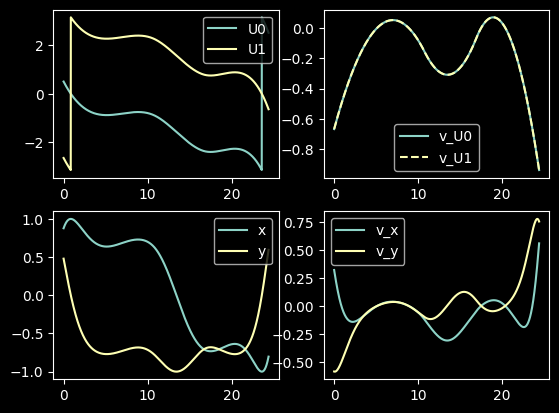

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

chart_regular, chart_antipodal = s1.charts

traj_regular, traj_regular_vel = traj.intrinsic[chart_regular]
traj_antipodal, traj_antipodal_vel = traj.intrinsic[chart_antipodal]

ax1.plot(traj.time, traj_regular, label=chart_regular)
ax1.plot(traj.time, traj_antipodal, label=chart_antipodal)
ax1.legend()

ax2.plot(traj.time, traj_regular_vel, label=f"v_{chart_regular}")
ax2.plot(traj.time, traj_antipodal_vel, "--", label=f"v_{chart_antipodal}")
ax2.legend()

traj_extrinsic, traj_extrinsic_vel = traj.extrinsic

ax3.plot(traj.time, traj_extrinsic, label=["x", "y"])
ax3.legend()

ax4.plot(traj.time, traj_extrinsic_vel, label=["v_x", "v_y"])
ax4.legend()

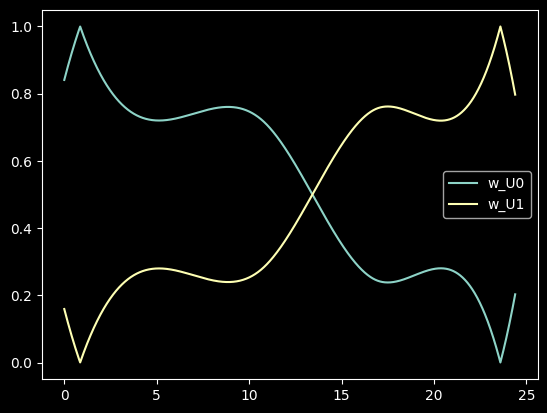

In [7]:
fig, ax = plt.subplots(1, 1)

traj_regular_weights = s1.intrinsic_weights_batch(chart_regular, torch.tensor(traj_regular))
traj_antipodal_weights = s1.intrinsic_weights_batch(chart_antipodal, torch.tensor(traj_antipodal))

ax.plot(traj.time, traj_regular_weights, label=f"w_{chart_regular}")
ax.plot(traj.time, traj_antipodal_weights, label=f"w_{chart_antipodal}")

ax.legend()